In [1]:
#%matplotlib notebook

import numpy as np
import argparse
import pickle
import matplotlib.pyplot as plt
import re
from itertools import islice
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

import glob
from tqdm import tqdm
import sys, os

from gemmi import read_pdb

### Some settings

In [2]:
protein_to_ranges = {
    "prion": [(0, 3), (10, 16), (40, 50), (65, 75), (86, 89), (95, 103)],
    "lyso": [(7, 12), (14, 17), (18, 25), (37, 48), (49, 56), (57, 77)],
    "abl": [(16, 26), (27, 36), (38, 48), (70, 80), (145, 170), (195, 200)],
}
def calculate_perresidue_distance(structure1, structure2):
    """Calculate the mean distance between atoms in corresponding residues."""
    mean_distances = []
    for model1, model2 in zip(structure1, structure2):
        for chain1, chain2 in zip(model1, model2):
            for residue1, residue2 in zip(chain1, chain2):
                if len(residue1) == len(
                    residue2
                ):  # Check if residues have the same number of atoms
                    distances = [
                        np.linalg.norm(
                            np.array(a1.pos.tolist()) - np.array(a2.pos.tolist())
                        )
                        for a1, a2 in zip(residue1, residue2)
                    ]
                    mean_distance = np.mean(distances)
                    mean_distances.append(mean_distance)
    return mean_distances

def get_resinfo(path, protein_type):
    iterations = int(re.search(r"it(\d+)", path).group(1))
    pdb_filei = f"{path}/0_postRBR.pdb"
    pdb_filef = f"{path}/{iterations-1}_postRBR.pdb"
    structurei = read_pdb(pdb_filei)
    structuref = read_pdb(pdb_filef)
    perres_distaces_tostart = calculate_perresidue_distance(structurei, structuref)
    residue_numbers = [residue.seqid.num for residue in structurei[0][0]]
    ranges = protein_to_ranges[protein_type]
    bfactor_data = {range_: [] for range_ in ranges}
    for i in range(iterations - 1):
        pdb_file1 = f"{path}/{i}_postRBR.pdb"
        pdb_file2 = f"{path}/{i+1}_postRBR.pdb"
        structure1 = read_pdb(pdb_file1)
        structure2 = read_pdb(pdb_file2)
        # Initialize a dictionary to store B-factor values for each residue range in the current iteration
        iteration_data = {range_: [] for range_ in ranges}
        # Iterate through atoms
        for chain in structure1[0]:
            for residue in chain:
                residue_number = residue.seqid.num
                # Check if the residue is within any specified range
                for range_ in ranges:
                    if range_[0] <= residue_number <= range_[1]:
                        # Extract B-factor value
                        bfactor = residue[0].b_iso
                        # Append B-factor value to the corresponding range and iteration
                        iteration_data[range_].append(bfactor)
        # Store the mean B-factor for each residue range in the current iteration
        for range_, data_b in iteration_data.items():
            mean_b_factor = np.mean(data_b)
            bfactor_data[range_].append((i, mean_b_factor))
            if i == 8:
                bfactor_data[range_].append((i + 1, mean_b_factor))
        
    return residue_numbers,perres_distaces_tostart, bfactor_data

In [3]:
sns.set_context("notebook", font_scale=1.8)
plt.rcParams["axes.linewidth"] = 3.0
plt.rcParams["axes.edgecolor"] = "slategrey"
plt.rcParams["xtick.color"] = "slategrey"
plt.rcParams["ytick.color"] = "slategrey"
plt.rcParams["axes.labelcolor"] = "slategrey"

In [4]:
# Ranges of interest
protein_to_labels = {
    "prion": [
        "N-terminus",
        "Loop",
        "Small Helix",
        "Hinge",
        "Control",
        "C-terminus Helix",
    ],
    "lyso": [
        "Control",
        "Small Beta Sheet",
        "Beta+Loop",
        "Short Helix",
        "Helices Loop",
        "Long Helix",
    ],
    "abl": [
        "Gly Loop",
        "Beta+Loop",
        "Loop Connection",
        "Beta+Loop+Beta",
        "DFG Loop",
        "Control",
    ],
}

In [5]:
def shared_y(ax, x, y1, y2, colors, labels, format="%.1f", y3=None, share_ylim=False):
    ax2 = ax.twinx()
    ax.plot(x, y1, color=colors[0], linewidth=4)
    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1], color=colors[0])
    ax.tick_params(axis="y", labelcolor=colors[0])
    ax.yaxis.set_major_formatter(FormatStrFormatter(format))

    ax2.plot(x, y2, color=colors[1], linewidth=4, linestyle="--")
    if y3 is not None:
        ax2.plot(x, y3, color=colors[-1], linewidth=4, linestyle="-")
    ax2.set_ylabel(labels[-1], color=colors[1])
    ax2.tick_params(axis="y", labelcolor=colors[1])
    ax2.yaxis.set_major_formatter(FormatStrFormatter(format))
    if share_ylim:
        ymin = min(np.min(y1), np.min(y2))-0.02
        ymax = max(np.max(y1), np.max(y2))+0.02
        ax.set_ylim(ymin,ymax)
        ax2.set_ylim(ymin,ymax)

In [6]:
def results_plot(path, protein_type, save=False):
    
    title_labels = protein_to_labels[protein_type]
    iterations_len = int(re.search(r"it(\d+)", path).group(1))
    
    # Load LLG per iteration
    LLGs = np.load("{path}/LLG_it.npy".format(path=path))

    # Load r factors per iteration
    Rfrees = np.load("{path}/rfree_it.npy".format(path=path))
    Rworks = np.load("{path}/rwork_it.npy".format(path=path))

    # Load MSE loss matrix
    MSE_loss_matrix = np.load("{path}/MSE_loss_it.npy".format(path=path))

    # Load mean plddt per iteration
    plddt_per_it = np.load("{path}/mean_it_plddt.npy".format(path=path))

    # Load mean plddt per residue
    plddt_per_residue = np.load("{path}/mean_plddt_res.npy".format(path=path))

    # Load residue shifts
    try:
        residue_numbers = np.load("{path}/residue_numbers.npy".format(path=path))
        mean_perresidue_tostart = np.load(
            "{path}/meanshift_perresidue_tostart.npy".format(path=path)
        )
        mean_perresidue = np.load("{path}/meanshift_perresidue.npy".format(path=path))
        
        with open("{path}/pseudoB_lineouts_data.pkl".format(path=path), "rb") as file:
            pseudob_data = pickle.load(file)
    except:
        residue_numbers, mean_perresidue_tostart, pseudob_data = get_resinfo(path=path, protein_type=protein_type)

    fig = plt.figure(layout="constrained", figsize=(30, 14))
    subfigs = fig.subfigures(
        2, 3, wspace=0.1, width_ratios=[1.3, 1, 1], height_ratios=[1, 1]
    )

    tl_ax = subfigs[0, 0].subplots(1, 1)
    shared_y(
        tl_ax,
        range(iterations_len),
        LLGs,
        plddt_per_it,
        ["mediumblue", "cornflowerblue"],
        ["Iteration", "-LLG", "Mean pLDDT (Over Residues)"],
    )

    # Subfig [0,1]
    # Plot lineouts for each range in the first column
    tr_ax = subfigs[0, 1].subplots(2, 1, sharex=True)
    for i, (range_, data_b) in enumerate(islice(pseudob_data.items(), 2)):
        iterations, mean_b_factors = zip(*data_b)
        average_lineout = np.mean(MSE_loss_matrix[:, range_[0] : range_[1]], axis=1)
        shared_y(
            tr_ax[i],
            np.arange(iterations_len),
            average_lineout,
            mean_b_factors,
            ["slategrey", "darkslategrey"],
            ["", "", ""],
        )
        tr_ax[i].grid(True)
        tr_ax[i].set_ylabel("{start}-{end}".format(start=range_[0], end=range_[1]))
    tr_ax[0].set_title(title_labels[0], color="darkslategrey")
    tr_ax[1].set_title(title_labels[1], color="darkslategrey")
    tr_ax[-1].set_xlabel("Iteration")

    # Subfig [0,2]
    tr_ax = subfigs[0, 2].subplots(2, 1, sharex=True)
    for i, (range_, data_b) in enumerate(islice(pseudob_data.items(), 2, 4)):
        iterations, mean_b_factors = zip(*data_b)
        average_lineout = np.mean(MSE_loss_matrix[:, range_[0] : range_[1]], axis=1)
        shared_y(
            tr_ax[i],
            np.arange(iterations_len),
            average_lineout,
            mean_b_factors,
            ["slategrey", "darkslategrey"],
            ["", "", ""],
        )
        tr_ax[i].grid(True)
        tr_ax[i].set_ylabel("{start}-{end}".format(start=range_[0], end=range_[1]))
    tr_ax[0].set_title(title_labels[2], color="darkslategrey")
    tr_ax[1].set_title(title_labels[3], color="darkslategrey")
    tr_ax[-1].set_xlabel("Iteration")

    # Subfig [1,2]
    tr_ax = subfigs[1, 2].subplots(2, 1, sharex=True)
    for i, (range_, data_b) in enumerate(islice(pseudob_data.items(), 4, 6)):
        iterations, mean_b_factors = zip(*data_b)
        average_lineout = np.mean(MSE_loss_matrix[:, range_[0] : range_[1]], axis=1)
        shared_y(
            tr_ax[i],
            np.arange(iterations_len),
            average_lineout,
            mean_b_factors,
            ["slategrey", "darkslategrey"],
            ["", "", ""],
        )
        tr_ax[i].grid(True)
        tr_ax[i].set_ylabel("{start}-{end}".format(start=range_[0], end=range_[1]))
    tr_ax[0].set_title(title_labels[4], color="darkslategrey")
    tr_ax[1].set_title(title_labels[5], color="darkslategrey")
    tr_ax[-1].set_xlabel("Iteration")

    # Subfig [1,0]
    bl_ax = subfigs[1, 0].subplots(1, 1)
    shared_y(
        bl_ax,
        residue_numbers,
        plddt_per_residue,
        mean_perresidue_tostart,
        ["darkslategrey", "silver"],
        [
            "Residue",
            "Mean pLDDT (Over Iterations)",
            "Mean Residue Shift",
        ],
        #y3=mean_perresidue,
    )

    # Subfig [1,1]
    rf_ax = subfigs[1, 1].subplots(1, 1)
    shared_y(
        rf_ax,
        range(iterations_len),
        Rfrees,
        Rworks,
        ["maroon", "salmon"],
        ["Iteration", "Rfree", "Rwork"],
        format="%.2f",
        share_ylim=True
    )
    

    fig.suptitle("{}".format(os.path.basename(path)), fontsize=18)
    plt.show()
    fig.savefig("{path}/results.pdf".format(path=path))

In [7]:
def heatmap_plot(path, protein_type):

    # Load MSE loss matrix
    MSE_loss_matrix = np.load("{path}/MSE_loss_it.npy".format(path=path))

    # Load MSA changes per iteration matrix
    MSA_changes_matrix = np.load("{path}/MSA_changes_it.npy".format(path=path))
    
    # Create a 2x1 subplot grid
    fig, subfigs = plt.subplots(2, 1, figsize=(30, 14))

    # Plot the top heatmap (MSE_loss_matrix)
    top_map = subfigs[0].imshow(MSE_loss_matrix.T, cmap="viridis", vmax=2.5)
    subfigs[0].set_xlabel("Iteration")
    subfigs[0].set_ylabel("Residue Calpha")
    subfigs[0].set_title("MSE Loss")

    # Add colorbar for the top heatmap
    top_colorbar = fig.colorbar(
        top_map,
        fraction=0.05,
        pad=0.05,
        shrink=0.9,
        ax=subfigs[0],
        label="MSE to True Position ($\mathrm{\AA}$)",
    )

    # Plot the bottom heatmap (MSA_changes_matrix)
    bottom_map = subfigs[1].imshow(MSA_changes_matrix.T, cmap="viridis")
    subfigs[1].set_xlabel("Iteration")
    subfigs[1].set_ylabel("Residue Calpha")
    subfigs[1].set_title("MSA Changes")

    # Add colorbar for the bottom heatmap
    bottom_colorbar = fig.colorbar(
        bottom_map,
        fraction=0.05,
        pad=0.05,
        shrink=0.9,
        ax=subfigs[1],
        label="Change in mean of MSA representation",
    )

    fig.suptitle("{}".format(os.path.basename(path)), fontsize=18)
    plt.tight_layout()
    plt.show()
    
    fig.savefig("{path}/results_heatmaps.pdf".format(path=path))

### 3hak test

In [ ]:
pri_paths = glob.glob("/net/cci/alisia/openfold_tests/run_openfold/test_cases/3hak/outputs/*3hak_it1000_v3_lr0.001+0.01_wdNone_batch1_subr1.0_solvTrue_scaleTrue_sigma*")

In [ ]:
print(pri_paths)

In [ ]:
results_plot(pri_paths[1], "prion")

In [ ]:
heatmap_plot(pri_paths[1], "prion")

### 6lzt test

In [ ]:
lyso_paths = glob.glob("/net/cci/alisia/openfold_tests/run_openfold/test_cases/6lzm/outputs/6lzm_it400*")

In [ ]:
lyso_paths

In [ ]:
results_plot(lyso_paths[1], "lyso")

In [ ]:
heatmap_plot(lyso_paths[3], "lyso")

### 3pyy test

In [8]:
abl_paths = glob.glob("/net/cci/alisia/openfold_tests/run_openfold/test_cases/7dt2_short/outputs/*working+v3*")
#"3pyy_short_it300_v3_lr0.001+0.001_wd0.0001_batch1_subr0.7_solvTrue_scaleTrue_resol_2.20_29.96_rbrlbfgs_150.0_aliB_L20.0+10.0_A"


In [9]:
abl_paths

['/net/cci/alisia/openfold_tests/run_openfold/test_cases/7dt2_short/outputs/7dt2_short_it2_v3_lr0.001+0.001_wdNone_batch1_subr1.0_solvTrue_scaleTrue_sigmaANone_resol_2.30_42.89_rbrlbfgs_150.0_aliB_L20.0+10.0_working+v3',
 '/net/cci/alisia/openfold_tests/run_openfold/test_cases/7dt2_short/outputs/7dt2_short_it400_v3_lr0.001+0.001_wdNone_batch1_subr1.0_solvTrue_scaleTrue_sigmaATrue_resol_2.30_42.89_rbrlbfgs_150.0_aliB_L20.0+10.0_working+v3']

In [ ]:
Rfrees = np.load("{path}/rfree_it.npy".format(path=abl_paths[0]))
Rworks = np.load("{path}/rwork_it.npy".format(path=abl_paths[0]))

In [ ]:
plt.plot(Rfrees, color="maroon", label="Rfree", linewidth=3)
plt.plot(Rworks, color="salmon", linestyle="--", label="Rwork", linewidth=3)
plt.xlabel("Iteration")
plt.ylim(0.39, 0.5)
plt.legend()
plt.show()

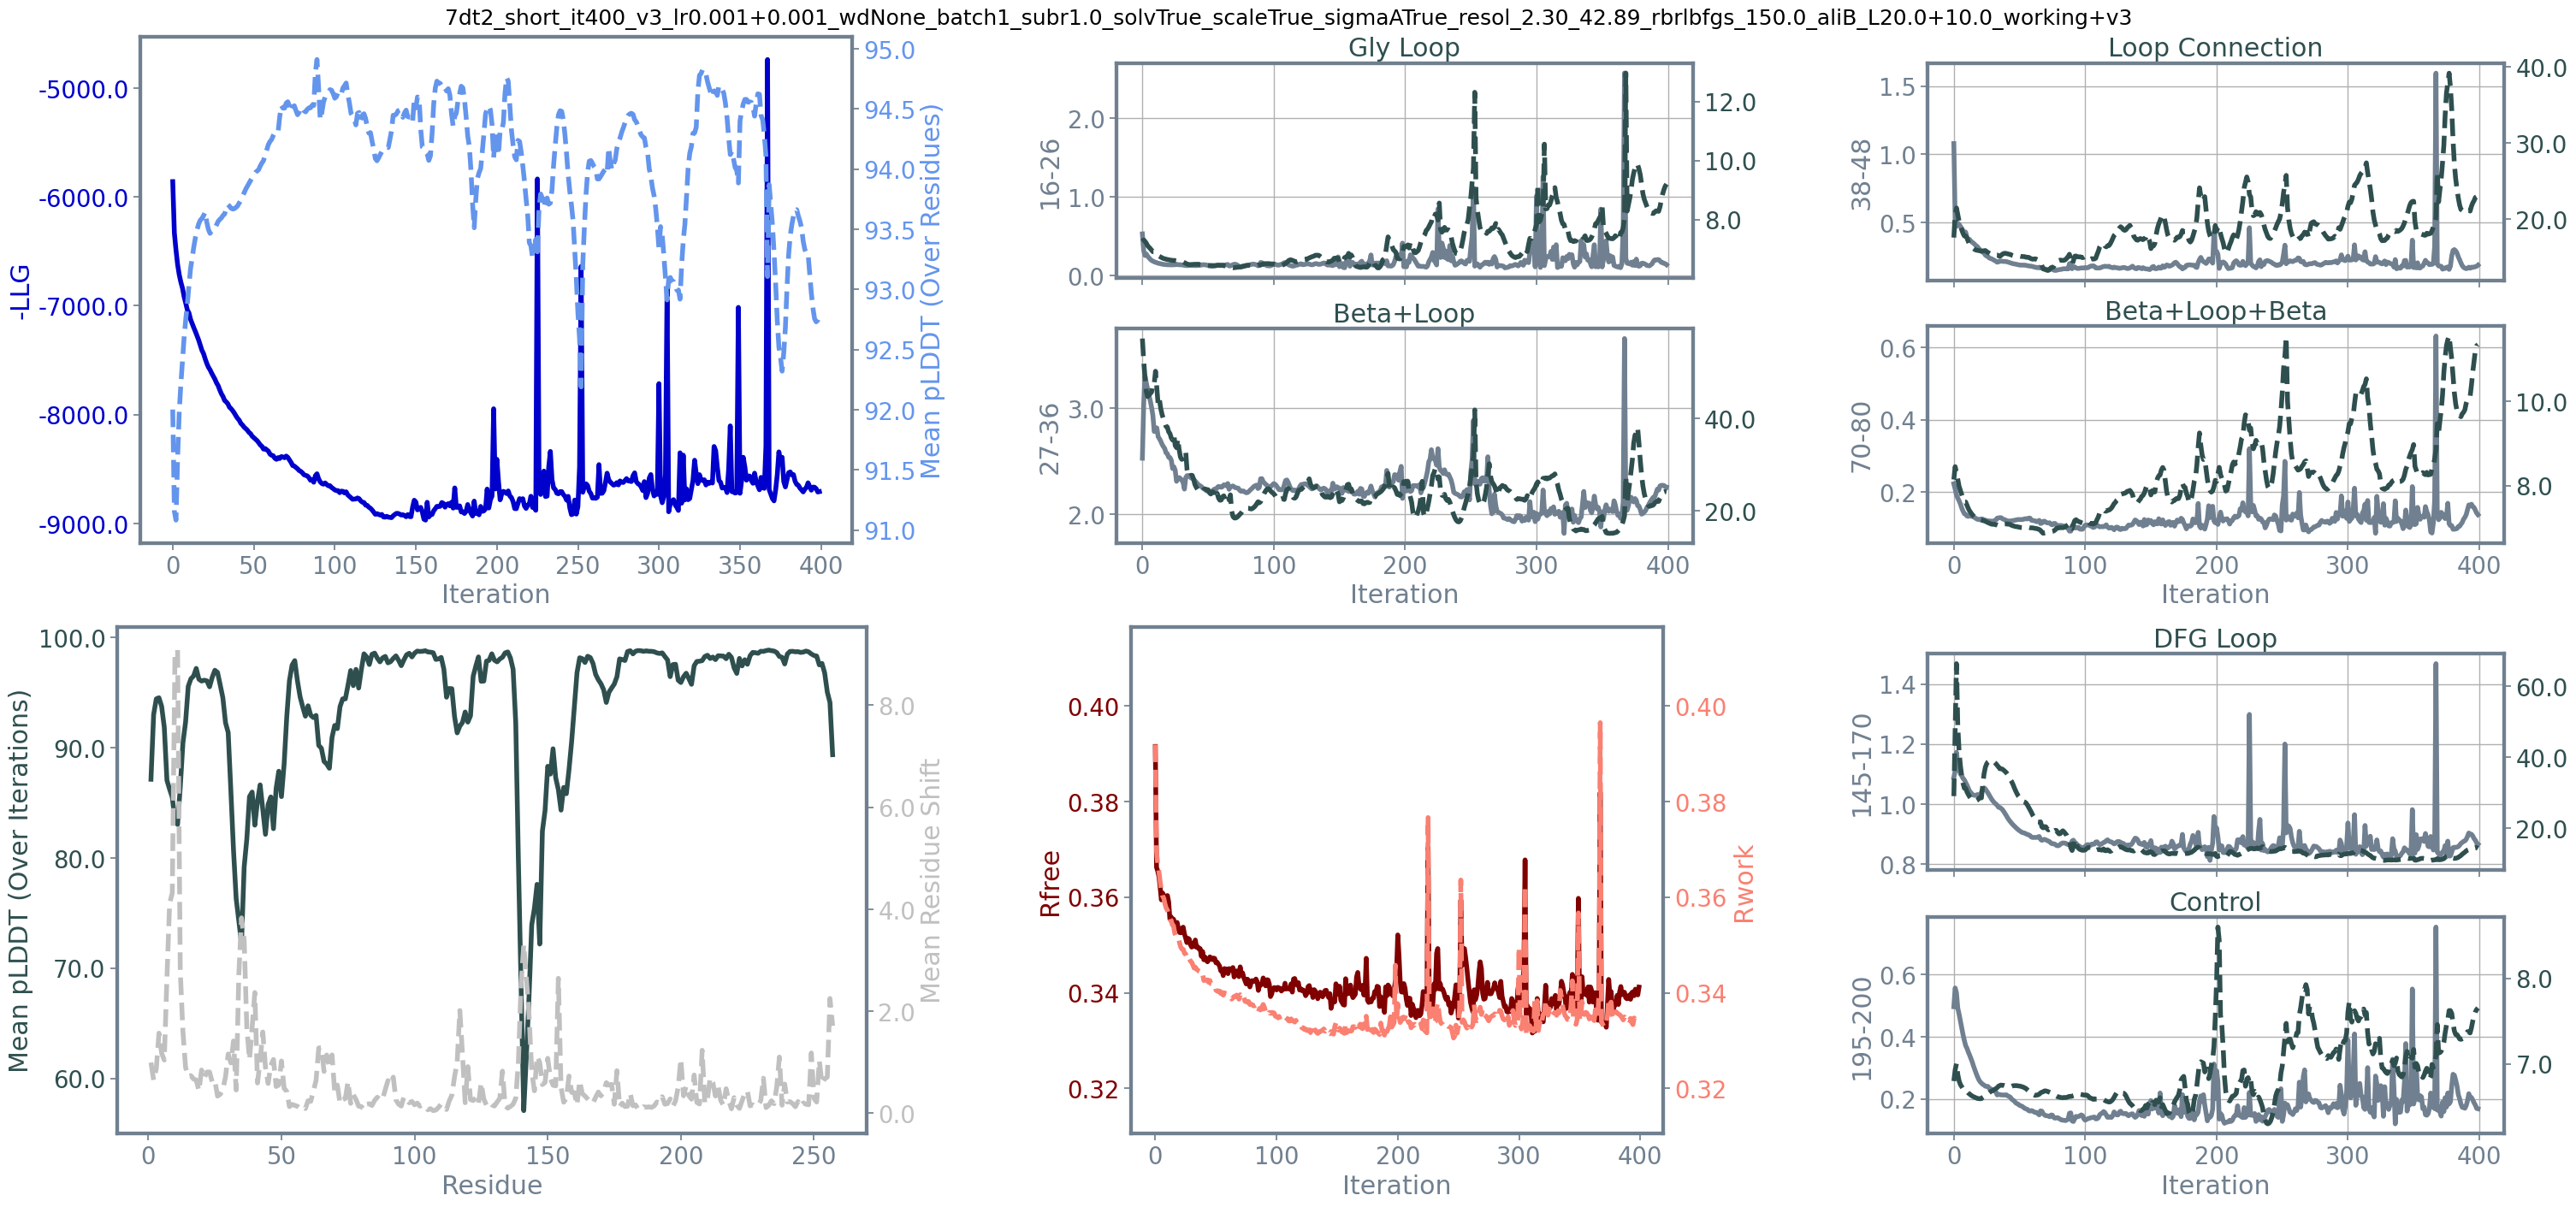

In [10]:
results_plot(abl_paths[1], "abl")

In [ ]:
heatmap_plot(abl_paths[2], "abl")

### 3hak production run

In [ ]:
pri_paths = glob.glob("./test_cases/3hak/outputs/*_Jan24*")

In [ ]:
for temp_path in tqdm(pri_paths):
    try:
        results_plot(temp_path, "prion")
        heatmap_plot(temp_path, "prion")
    except:
        print(temp_path, "Wrong")

### 6lzm production run

In [ ]:
lyso_paths = glob.glob("/net/cci/alisia/openfold_tests/run_openfold/test_cases/6lzm/outputs/6lzm_it400*")

In [ ]:
lyso_paths

In [ ]:
for temp_path in tqdm(lyso_paths):
    try:
        results_plot(temp_path, "lyso")
        heatmap_plot(temp_path, "lyso")
    except:
        print(temp_path, "Wrong")

### 3pyy

In [ ]:
abl_paths = glob.glob("./test_cases/3pyy_short/outputs/*_Jan24*")

In [ ]:
for temp_path in tqdm(abl_paths):
    try:
        results_plot(temp_path, "abl")
        heatmap_plot(temp_path, "abl")
    except:
        print(temp_path, "Wrong")

## Move plots to a folder

In [ ]:
import shutil

### Prion

In [ ]:
#pri_paths = glob.glob("./test_cases/3hak/outputs/*_Jan24*")
#target = "./test_cases/plots/3hak/"

In [ ]:
#for source_path in tqdm(pri_paths):
#    source_files = glob.glob(source_path + "/*[!pdb]")
#    if len(source_files) == 0:
#        print(source_path, "No file")
#        continue
#    print(source_path, f"{len(source_files)} files")
#    if not os.path.exists(target + os.path.basename(source_path)):
#        os.mkdir(target + os.path.basename(source_path))
#    for source_file in source_files:
#        shutil.copy(source_file, target + os.path.basename(source_path) + '/' + os.path.basename(source_file))

### 6lzm

In [ ]:
#lyso_paths = glob.glob("./test_cases/6lzm/outputs/*_Jan24*")
#target = "./test_cases/plots/6lzm/"

In [ ]:
#for source_path in tqdm(lyso_paths):
#    source_files = glob.glob(source_path + "/*[!pdb]")
#    if len(source_files) == 0:
#        print(source_path, "No file")
#        continue
#    print(source_path, f"{len(source_files)} files")
#    if not os.path.exists(target + os.path.basename(source_path)):
#        os.mkdir(target + os.path.basename(source_path))
#    for source_file in source_files:
#        shutil.copy(source_file, target + os.path.basename(source_path) + '/' + os.path.basename(source_file))

### 3pyy

In [ ]:
#abl_paths = glob.glob("./test_cases/3pyy_short/outputs/*_Jan24*")
#target = "./test_cases/plots/3pyy_short/"

In [ ]:
#for source_path in tqdm(abl_paths):
#    source_files = glob.glob(source_path + "/*[!pdb]")
#    if len(source_files) == 0:
#        print(source_path, "No file")
#        continue
#    print(source_path, f"{len(source_files)} files")
#    if not os.path.exists(target + os.path.basename(source_path)):
#        os.mkdir(target + os.path.basename(source_path))
#    for source_file in source_files:
#        shutil.copy(source_file, target + os.path.basename(source_path) + '/' + os.path.basename(source_file))